In [2]:
import pyspark
import pandas as pd

spark = pyspark.sql.SparkSession.builder.appName("pysaprk_python").getOrCreate()
df = spark.read.csv('banking.csv', header=True, inferSchema=True)
df.createOrReplaceTempView("banking")
df = df.toPandas()

In [3]:
# print 10 random words
# df.sample(fraction=0.5).show(10)
df.sample(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
20249,48,blue-collar,married,unknown,no,113,no,no,cellular,11,aug,104,13,-1,0,unknown,no
25156,54,management,divorced,primary,no,210,no,no,cellular,18,nov,178,1,-1,0,unknown,no
37103,39,technician,single,secondary,no,0,yes,no,cellular,13,may,6,7,175,4,other,no
33622,34,management,single,tertiary,no,6707,yes,no,cellular,20,apr,16,3,154,4,other,no
42978,58,technician,married,secondary,no,589,yes,no,cellular,10,feb,511,3,183,6,success,yes


In [4]:
# print(f"Ratio of loan takers from clients is: {100 * df.filter("loan == 'yes'").count() / df.count():.2f}%.")
df[df.loan == "yes"].count().iloc[0] / df.count().iloc[0] * 100

np.float64(16.022649355245406)

<Axes: xlabel='job'>

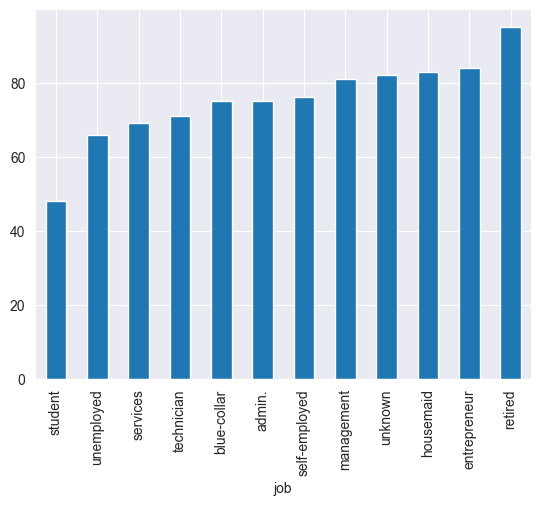

In [5]:
# oldest people in the profession
# df.groupby('job').max('age').show()
df.groupby('job')['age'].max().sort_values().plot(kind='bar')

In [6]:
# df.filter('job == "student"').agg({'age': 'median'}).show()
df[df.job == 'student'].groupby('job')['age'].median()

job
student    26.0
Name: age, dtype: float64

In [7]:
spark.catalog.listTables()

[Table(name='banking', catalog=None, namespace=[], description=None, tableType='TEMPORARY', isTemporary=True)]

In [8]:
spark.sql("SELECT AVG(age) as average_age FROM banking WHERE loan == 'yes'").show()

+-----------------+
|      average_age|
+-----------------+
|40.55563224737714|
+-----------------+



In [9]:
df[df.Target == "yes"].count().iloc[0] / df.count().iloc[0] * 100

np.float64(11.698480458295547)

Text(0.5, 1.0, 'Average age of marital status by profession')

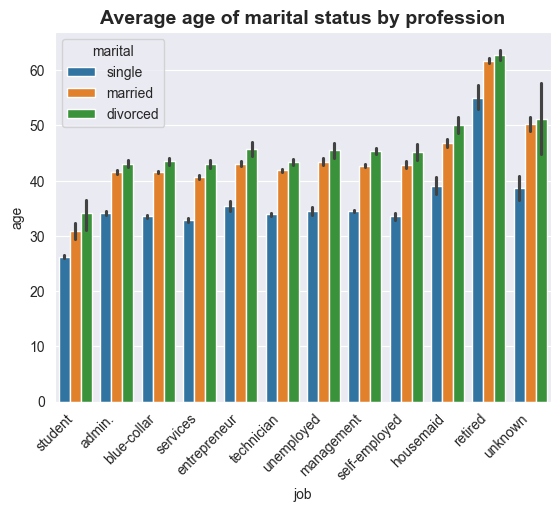

In [10]:
import seaborn as sns
ages_jobs = df.groupby('job').agg({'age': 'mean'}).sort_values('age', ascending=False)

ax = sns.barplot(data=df.sort_values(by='age'), x='job', y='age', hue='marital')
ax.set_xticks(df.job.unique())
ax.set_xticklabels(labels=df.job.unique(), rotation=45, ha='right',)
ax.set_title(
    label='Average age of marital status by profession',
    fontdict={'fontsize': 14, 'fontweight': 'bold'}
)

In [11]:
df[df.balance==df.balance.max()]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
39989,51,management,single,tertiary,no,102127,no,no,cellular,3,jun,90,1,-1,0,unknown,no


In [12]:
df[df.balance==df.balance.min()]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
12909,26,blue-collar,single,secondary,yes,-8019,no,yes,cellular,7,jul,299,3,-1,0,unknown,no


In [13]:
from matplotlib import pyplot as plt

df.default.value_counts().iloc[1] / df[df.loan=='yes'].count().iloc[0] * 100
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int32 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int32 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int32 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int32 
 12  campaign   45211 non-null  int32 
 13  pdays      45211 non-null  int32 
 14  previous   45211 non-null  int32 
 15  poutcome   45211 non-null  object
 16  Target     45211 non-null  object
dtypes: int32(7), object(10)
memory usage: 4.7+ MB


In [14]:
print("The proportion of clients who's balance is more than twice than the average balance is:")
print(f"{df[df.balance > df.balance.mean() * 2].count().iloc[0] / df.count().iloc[0] * 100:.2f}%")

The proportion of clients who's balance is more than twice than the average balance is:
13.82%


In [15]:
arr = df['education'].unique()
client_amount = spark.sql("SELECT * FROM banking").count()
education_amount = spark.sql("SELECT * FROM banking WHERE education = '{elem}'").count()

<Axes: >

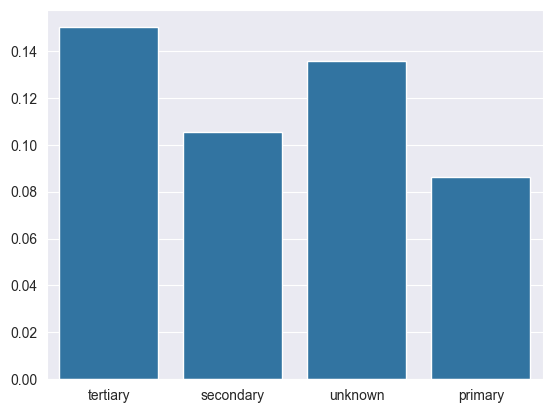

In [16]:
d = {}
for elem in arr:
    d[elem] = (spark.sql(f"SELECT * FROM banking WHERE Target == 'yes' AND education == '{elem}'").count() / spark.sql(f"SELECT * FROM banking WHERE education = '{elem}'").count())
sns.barplot(d)

In [17]:
import numpy as np
df['Target'] = df['Target'].replace({'yes': 1, 'no': 0})
df['loan'] = df['loan'].replace({'yes': 1, 'no': 0})
df['default'] = df['default'].replace({'yes': 1, 'no': 0})
corr_dict = {}
for col in df.columns:
    if (isinstance(df[col].iloc[0], np.int64) or isinstance(df[col].iloc[0], np.int32) or isinstance(df[col].iloc[0], np.float64)) and col != 'Target':
        corr_dict[col] = np.round(df['Target'].corr(df[col]) * 100, 2)



C:\Users\merda\AppData\Local\Temp\ipykernel_25940\2899504638.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Target'] = df['Target'].replace({'yes': 1, 'no': 0})
C:\Users\merda\AppData\Local\Temp\ipykernel_25940\2899504638.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['loan'] = df['loan'].replace({'yes': 1, 'no': 0})
C:\Users\merda\AppData\Local\Temp\ipykernel_25940\2899504638.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, e

([<matplotlib.axis.XTick at 0x222909902f0>,
 [Text(0, 0, '0'),
  Text(10, 0, '10'),
  Text(20, 0, '20'),
  Text(30, 0, '30'),
  Text(40, 0, '40'),
  Text(50, 0, '50'),
  Text(60, 0, '60'),
  Text(70, 0, '70'),
  Text(80, 0, '80'),
  Text(90, 0, '90'),
  Text(100, 0, '100')])

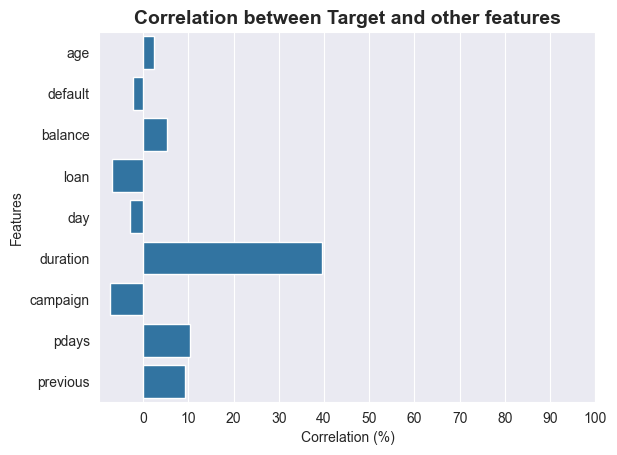

In [18]:
sns.barplot(corr_dict, orient='h')
plt.title(
    label='Correlation between Target and other features',
    fontdict={'fontsize': 14, 'fontweight': 'bold'}
)
plt.xlabel('Correlation (%)')
plt.ylabel('Features')
plt.xticks(
    ticks=np.arange(0, 101, 10),
    labels=np.arange(0, 101, 10)
)